# EDA — GoEmotions mapped to Wavelength's mood taxonomy

Source data: `ml/data/processed/{train,val,test}.csv`, produced by
`python -m vibe_ml.data.goemotions` (GoEmotions' 28 fine-grained emotions
mapped onto our 9-mood taxonomy via `vibe_ml.labels.GOEMOTIONS_TO_MOOD`;
multi-label and unmapped rows already dropped).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("..") / "data" / "processed"

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")
train_df.head()

train: 32755  val: 4113  test: 4141


,text,mood,source_label
0,My favourite food is anything I didn't have to...,neutral,neutral
1,"Now if he does off himself, everyone will thin...",neutral,neutral
2,WHY THE FUCK IS BAYLESS ISOING,angry,anger
3,To make her feel threatened,anxious,fear
4,Dirty Southern Wankers,angry,annoyance


## Mood label distribution (train)

Expect heavy imbalance — GoEmotions skews toward `neutral`/`happy`
(everyday Reddit comments), and several of our mood buckets have no
direct GoEmotions analogue.

mood
neutral     12823
happy        9857
angry        4376
romantic     2465
sad          1918
anxious       718
excited       510
calm           88
Name: count, dtype: int64

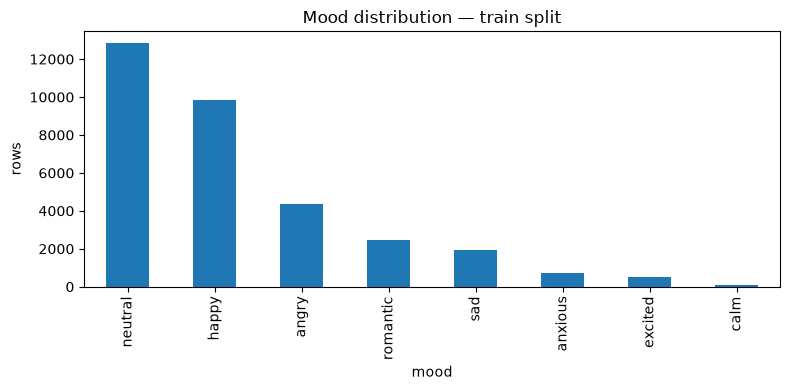

In [2]:
counts = train_df["mood"].value_counts()
display(counts)

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="bar", ax=ax)
ax.set_ylabel("rows")
ax.set_title("Mood distribution — train split")
fig.tight_layout()
plt.show()

## Known taxonomy gaps

`nostalgic` has zero rows — GoEmotions has no emotion that maps to it.
`calm` is extremely thin (only `relief` maps to it). Both are documented
gaps in `ml/data/README.md` and `ml/src/vibe_ml/labels.py`, not bugs.

In [3]:
from vibe_ml.labels import MOOD_LABELS

missing_or_thin = {m: int(counts.get(m, 0)) for m in MOOD_LABELS}
missing_or_thin

{'happy': 9857,
 'sad': 1918,
 'calm': 88,
 'anxious': 718,
 'angry': 4376,
 'excited': 510,
 'romantic': 2465,
 'nostalgic': 0,
 'neutral': 12823}

## Text length distribution

count    32755.000000
mean        12.523523
std          6.742824
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         32.000000
Name: text, dtype: float64


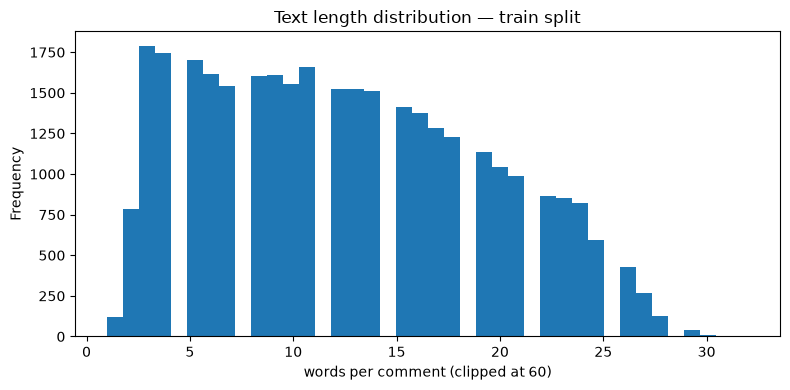

In [4]:
word_counts = train_df["text"].str.split().str.len()
print(word_counts.describe())

fig, ax = plt.subplots(figsize=(8, 4))
word_counts.clip(upper=60).plot(kind="hist", bins=40, ax=ax)
ax.set_xlabel("words per comment (clipped at 60)")
ax.set_title("Text length distribution — train split")
fig.tight_layout()
plt.show()

## Sample rows per mood

Quick sanity read — does the mapped label actually match how the text
reads?

In [5]:
for mood in sorted(train_df["mood"].unique()):
    print(f"\n=== {mood} ===")
    for text in train_df.loc[train_df["mood"] == mood, "text"].sample(min(3, (train_df["mood"] == mood).sum()), random_state=0):
        print("-", text)


=== angry ===
- You cant.Its the idiot civilian drivers fault for probably just staying behind him like a zombie. Unless they come out with heated trailers soon.
- What the hell is going on at Getty Images?
- I just mean symbolically it's weird to call your own flesh a 'blanket'.

=== anxious ===
- Bedside report is terrible.
- The fact that you think like this is terrifying.
- An indie rock guy I loved used dialectics to explain his songwriting process, it was weird.

=== calm ===
- I’m glad you fixed Minnesota, because there is a 0% chance we will go Red.
- Thank goodness I’m safe. Don’t sound so disappointed.
- I'm glad I'm not the only one who feels the same!

=== excited ===
- It's a miracle! This is how religions start.
- Anything to do with Iceland and Scandinavia has to be rad!
- Happy cake day bruh

=== happy ===
- You can do it, I believe in you! 
- Good luck friend.
- Thanks for the response.

=== neutral ===
- Its like a tiny hat. A silly itty bitty hat.
- Hey he's not the

## Baseline results (for reference)

Trained via `python -m vibe_ml.training.train`, evaluated via
`python -m vibe_ml.evaluation.evaluate` — see `ml/models/latest/metrics.json`
and `confusion_matrix.png` for the full breakdown. As expected, `calm` and
`excited` (the smallest classes) are the weakest; `happy`/`neutral`
(largest classes) are the strongest.